## This project builds an automated pipeline to analyze and visualize stock price performance across multiple companies and indices.

## It replaces a manual Excel-based workflow with a reproducible, scalable system that integrates data fetching, transformation, and high-quality visualization into a single process.

## The output is a presentation-ready chart with standardized time series, relative performance comparison, and intelligent labeling.

### Note: Please download all required company logos and save them in the same directory as the script before execution.

#### This cell below contains the required Python packages for the code. If you are running it for the first time, remove the “#” and run the cell. Once installed, there is no need to repeat this step in future runs.

In [1]:
# pip install yfinance pandas matplotlib numpy pillow

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from PIL import Image
import os

### share price analysis from 2020-2026

In [2]:
# ── 0) Layout and Annotation Parameters (adjust only here to fine-tune layout) ──
SUBPLOT_LEFT   = 0.10   # Left margin of the subplot (relative to canvas)
SUBPLOT_RIGHT  = 0.88   # Right margin of the subplot
SUBPLOT_TOP    = 0.89   # Top margin of the subplot
SUBPLOT_BOTTOM = 0.09   # Bottom margin of the subplot

RIGHT_PAD_FRAC   = 0.15    # Right-side blank space, as a fraction of the plot's time-axis width
PCT_OFFSET_FRAC  = 0.020   # Percentage-label offset, as a fraction of the plot's time-axis width
LOGO_OFFSET_FRAC = 0.070   # Logo offset, as a fraction of the plot's time-axis width

VERT_MARGIN_PX     = 1      # Additional vertical safety margin in pixels to avoid overlap (smaller = tighter)
TEXT_FONTSIZE_PT   = 9.5    # Font size for percentage labels
LOGO_REL_HEIGHT    = 0.08   # Target logo height relative to the canvas height (recommended: 0.07–0.10)
LOGO_MAX_SCALE_UP  = 1.0    # Prevent upscaling: 1.0 means do not enlarge beyond original size; >1 allows limited scaling

LOGO_SCALE_OVERRIDES = {
    "DAX":        0.45,
    "SAP":        0.55,
    "Salesforce": 0.69,
    "Workday":    0.67,
}

# ── 1) Configuration ───────────────────────────────────────────────────────────
START    = "2020-01-01"
END      = "2026-07-06"
LOGO_DIR = os.getcwd()

tickers = {
    "Oracle":     "ORCL",
    "Nasdaq":     "^IXIC",
    "ServiceNow": "NOW",
    "DAX":        "^GDAXI",
    "SAP":        "SAP",
    "Salesforce": "CRM",
    "Workday":    "WDAY",
}

COLORS = {
    "Oracle":     "#FB0512",
    "Nasdaq":     "#0C5F75",
    "ServiceNow": "#00A8A8",
    "DAX":        "#70AD47",
    "SAP":        "#0070F2",
    "Salesforce": "#C815AC",
    "Workday":    "#F0AB00",
}

STYLES = {
    "Oracle":     {"lw": 1.8, "ls": "-"},
    "Nasdaq":     {"lw": 1.8, "ls": "--"},
    "ServiceNow": {"lw": 1.5, "ls": "-"},
    "DAX":        {"lw": 1.5, "ls": "--"},
    "SAP":        {"lw": 1.5, "ls": "-"},
    "Salesforce": {"lw": 1.5, "ls": "-"},
    "Workday":    {"lw": 1.5, "ls": "-"},
}

LOGO_FILES = {
    "Oracle":     "oracle_logo.png",
    "Nasdaq":     "nasdaq_logo.png",
    "ServiceNow": "servicenow_logo.png",
    "DAX":        "dax_logo.png",
    "SAP":        "sap_logo.png",
    "Salesforce": "salesforce_logo.png",
    "Workday":    "workday_logo.png",
}

Data saved → stock_prices_weekly.csv / stock_prices_weekly.xlsx
Saved → share_price_performance.png


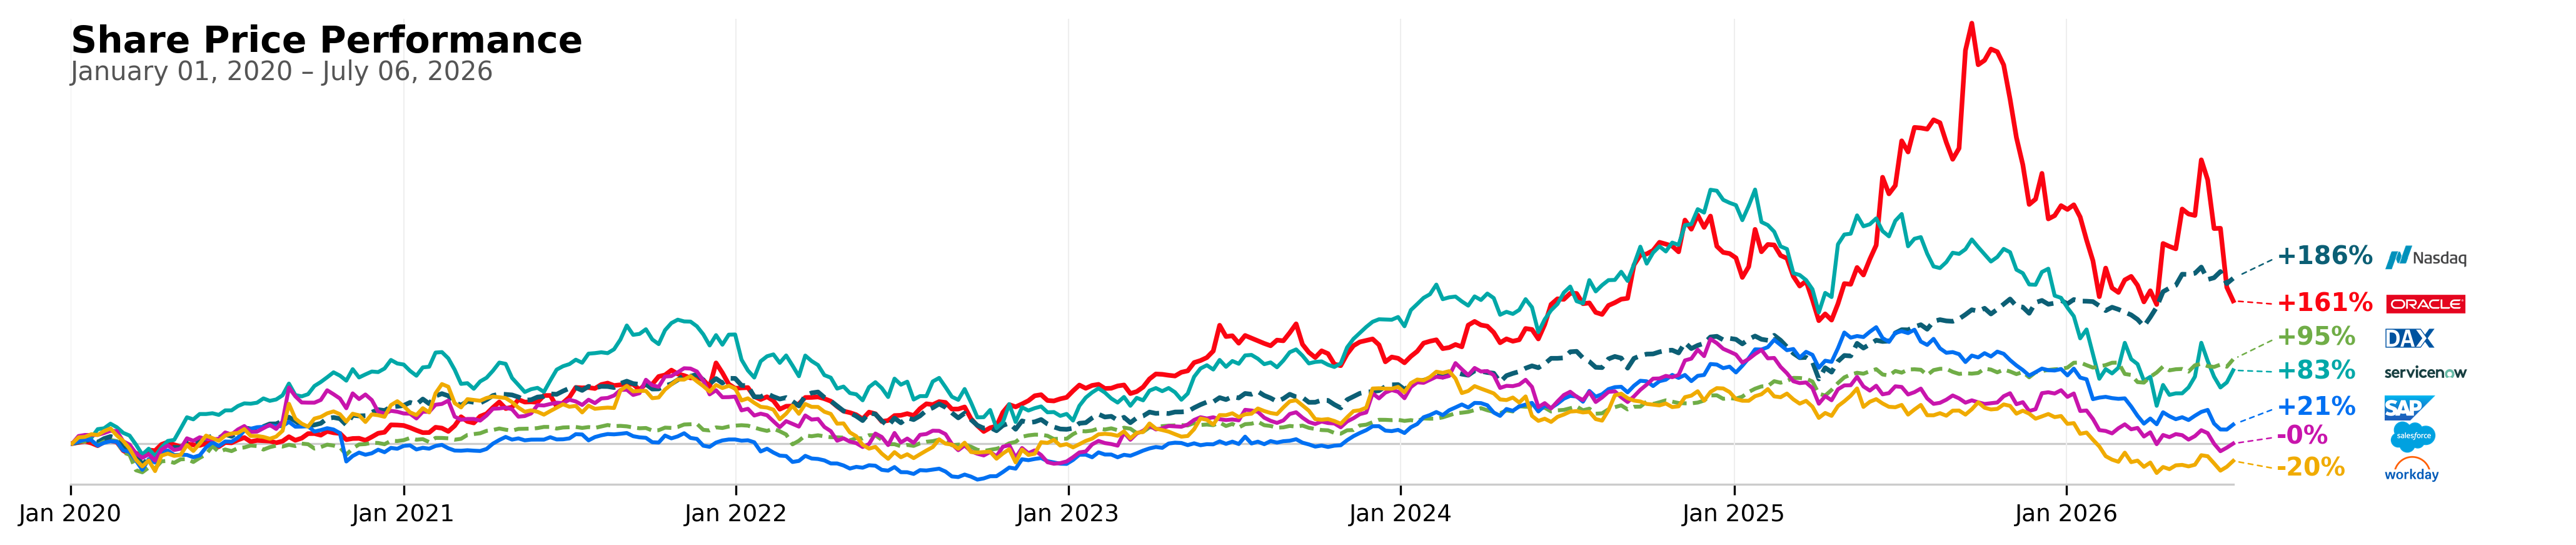

In [3]:
# ── 2) Data Retrieval ─────────────────────────────────────────────────────────
def fetch(ticker, start, end):
    df = yf.download(
        ticker, start=start, end=end,
        interval="1d", auto_adjust=False, progress=False
    )
    s = df.get("Close")
    if s is None or s.empty:
        return pd.Series(dtype=float)
    return s.resample("W-FRI").last().ffill()


raw = {label: fetch(tck, START, END) for label, tck in tickers.items()}

raw_df = pd.concat(raw, axis=1)
raw_df.to_csv("stock_prices_weekly.csv")
raw_df.to_excel("stock_prices_weekly.xlsx")
print("Data saved → stock_prices_weekly.csv / stock_prices_weekly.xlsx")


# ── 3) Data Alignment & Performance Calculation ──────────────────────────────
prices = pd.concat(list(raw.values()), axis=1, keys=list(raw.keys())).sort_index()
prices.columns = prices.columns.get_level_values(0)
prices = prices.dropna(how="all")
base_date = prices.dropna().index[0]
perf = (prices / prices.loc[base_date] - 1) * 100


# ── 4) Figure Setup ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 3.1), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plt.subplots_adjust(
    left=SUBPLOT_LEFT, right=SUBPLOT_RIGHT,
    top=SUBPLOT_TOP, bottom=SUBPLOT_BOTTOM
)


# ── 5) Plot Time Series ──────────────────────────────────────────────────────
for label in tickers:
    if label in perf:
        ax.plot(
            perf[label].index, perf[label].values,
            color=COLORS[label], linewidth=STYLES[label]["lw"],
            linestyle=STYLES[label]["ls"], zorder=3
        )


# ── 6) Axis Styling ──────────────────────────────────────────────────────────


# X-axis: one tick per year (Jan), labelled "Jan YYYY", only up to Jan 2026
tick_dates = pd.date_range("2020-01-01", "2026-01-01", freq="YS")
ax.set_xticks(tick_dates)
ax.set_xticklabels([d.strftime("Jan %Y") for d in tick_dates])

# Measure the plot's pixel width using the real data range (no padding yet)
ax.set_xlim(left=pd.Timestamp("2020-01-01"), right=prices.index[-1])
fig.canvas.draw()
axis_width_px = ax.get_window_extent().width
total_days = (prices.index[-1] - pd.Timestamp("2020-01-01")).days
px_per_day = axis_width_px / total_days

def frac_to_timedelta(frac):
    return pd.Timedelta(days=(axis_width_px * frac) / px_per_day)

RIGHT_PAD   = frac_to_timedelta(RIGHT_PAD_FRAC)
PCT_OFFSET  = frac_to_timedelta(PCT_OFFSET_FRAC)
LOGO_OFFSET = frac_to_timedelta(LOGO_OFFSET_FRAC)

# Now set the real x-limits, including the right-side padding
ax.set_xlim(
    left=pd.Timestamp("2020-01-01"),
    right=prices.index[-1] + RIGHT_PAD
)
ax.plot([ax.get_xlim()[0], mdates.date2num(prices.index[-1])], [0, 0],
        color="#cccccc", lw=0.8, zorder=1)

ax.tick_params(axis="x", labelsize=9, length=4)
ax.yaxis.set_visible(False)

for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.spines["bottom"].set_bounds(ax.get_xlim()[0], mdates.date2num(prices.index[-1]))

ax.grid(axis="x", color="#eeeeee", lw=0.5)
ax.margins(y=0.01)


# ── 7) High-Quality Logo Loading ─────────────────────────────────────────────
fig.canvas.draw()
fig_w_px, fig_h_px = (fig.get_size_inches() * fig.dpi)
target_logo_h = int(round(fig_h_px * LOGO_REL_HEIGHT))


def load_logo_best(path, target_h_pix, max_scale_up=1.0):
    img = Image.open(path).convert("RGBA")
    w, h = img.size
    allowed_h = int(round(min(h * max_scale_up, target_h_pix)))
    final_h = max(1, allowed_h)
    if final_h != h:
        new_w = int(round(w * final_h / h))
        img = img.resize((new_w, final_h), Image.LANCZOS)
        w, h = new_w, final_h
    return np.array(img), h, w, img


logos = {}
logo_heights = {}
logo_widths = {}

for label, fname in LOGO_FILES.items():
    path = os.path.join(LOGO_DIR, fname)
    if os.path.exists(path):
        scale = LOGO_SCALE_OVERRIDES.get(label, 1.0)
        arr, final_h, final_w, _ = load_logo_best(
            path, int(target_logo_h * scale), LOGO_MAX_SCALE_UP)
        logos[label] = arr
        logo_heights[label] = final_h
        logo_widths[label] = final_w


# ── 8) Dynamic Right-Side Label Layout (Pixel-Based Collision Avoidance) ─────
final_vals = {lbl: perf[lbl].dropna().iloc[-1] for lbl in perf.columns}
sorted_labels = sorted(final_vals, key=final_vals.get, reverse=True)
base_logo_x = prices.index[-1] + LOGO_OFFSET

last_valid_x = {}
for lbl in sorted_labels:
    s = perf[lbl].dropna()
    last_valid_x[lbl] = s.index[-1] if len(s) else prices.index[-1]

logo_x = base_logo_x


def data_y_to_pix(y):
    return ax.transData.transform((mdates.date2num(logo_x), y))[1]

def pix_to_data_y(pix):
    return ax.transData.inverted().transform((mdates.date2num(logo_x), pix))[1]

def pix_per_data_unit():
    p0 = data_y_to_pix(0.0)
    p1 = data_y_to_pix(1.0)
    return (p1 - p0) if (p1 - p0) != 0 else 1.0

def data_dy_from_pix(dy_pix):
    return dy_pix / pix_per_data_unit()


text_px = int(round(fig.dpi * TEXT_FONTSIZE_PT / 72.0))
base_text_gap_px = text_px + 4
margin_px = VERT_MARGIN_PX

ax_bbox = ax.get_window_extent()
y_min_pix = ax_bbox.y0
y_max_pix = ax_bbox.y1

adj_pix = [data_y_to_pix(final_vals[lbl]) for lbl in sorted_labels]
item_heights = [logo_heights.get(lbl, base_text_gap_px) for lbl in sorted_labels]

for _ in range(200):
    moved = False
    for i in range(1, len(adj_pix)):
        prev_h = item_heights[i - 1]
        curr_h = item_heights[i]
        min_gap_px = (prev_h / 2) + (curr_h / 2) + margin_px
        overlap = min_gap_px - (adj_pix[i - 1] - adj_pix[i])
        if overlap > 0.5:
            adj_pix[i - 1] += overlap / 2
            adj_pix[i]     -= overlap / 2
            moved = True
    if adj_pix[0] + item_heights[0] / 2 > y_max_pix:
        adj_pix[0] = y_max_pix - item_heights[0] / 2
        moved = True
    if adj_pix[-1] - item_heights[-1] / 2 < y_min_pix:
        shift = y_min_pix - (adj_pix[-1] - item_heights[-1] / 2)
        adj_pix = [p + shift for p in adj_pix]
        moved = True
    if not moved:
        break

positions = {lbl: pix_to_data_y(adj_pix[i]) for i, lbl in enumerate(sorted_labels)}


# ── 9) Percentage Labels & Leader Lines ──────────────────────────────────────
PCT_X = prices.index[-1] + PCT_OFFSET

for label in sorted_labels:
    val   = final_vals[label]
    y_adj = positions[label]
    y_raw = final_vals[label]
    x_end = last_valid_x[label]
    sign  = "+" if val >= 0 else ""

    if abs(y_adj - y_raw) > 1.0:
        ax.annotate(
            "", xy=(x_end, y_raw), xytext=(PCT_X, y_adj),
            arrowprops=dict(arrowstyle="-", color=COLORS[label],
                            lw=0.6, linestyle=(0, (3, 3)),
                            connectionstyle="arc3,rad=0.0"),
            annotation_clip=False, zorder=2,
        )

    ax.annotate(
        f"{sign}{val:.0f}%", xy=(PCT_X, y_adj),
        fontsize=TEXT_FONTSIZE_PT, color=COLORS[label],
        va="center", ha="left", fontweight="bold",
        annotation_clip=False, zorder=9,
    )


# ── 10) Logo Rendering (Pixel-Precise Placement) ─────────────────────────────
fig.canvas.draw()

for label in sorted_labels:
    if label not in logos:
        continue
    img_arr = logos[label]
    y_data  = positions[label]
    x_disp, y_disp = ax.transData.transform((mdates.date2num(logo_x), y_data))
    h_px = img_arr.shape[0]
    w_px = img_arr.shape[1]
    fig_w_px, fig_h_px = (fig.get_size_inches() * fig.dpi)
    x0     = x_disp / fig_w_px
    y0     = (y_disp - h_px / 2) / fig_h_px
    w_frac = w_px / fig_w_px
    h_frac = h_px / fig_h_px
    logo_ax = fig.add_axes([x0, y0, w_frac, h_frac], zorder=10)
    logo_ax.imshow(img_arr, aspect="auto", interpolation="none")
    logo_ax.axis("off")


# ── 11) Figure Title ─────────────────────────────────────────────────────────
fig.text(0.10, 0.88, "Share Price Performance",
         fontsize=14, fontweight="bold", va="top", ha="left")
fig.text(0.1, 0.82,
         f"{pd.Timestamp(START).strftime('%B %d, %Y')} – "
         f"{pd.Timestamp(END).strftime('%B %d, %Y')}",
         fontsize=10, color="#555555", va="top", ha="left")


# ── 12) Export Figure ───────────────────────────────────────────────────────
plt.savefig("share_price_performance.png", dpi=300)
print("Saved → share_price_performance.png")
plt.show()

### share price for the past year

Saved → share_price_performance_last_year_v2.png


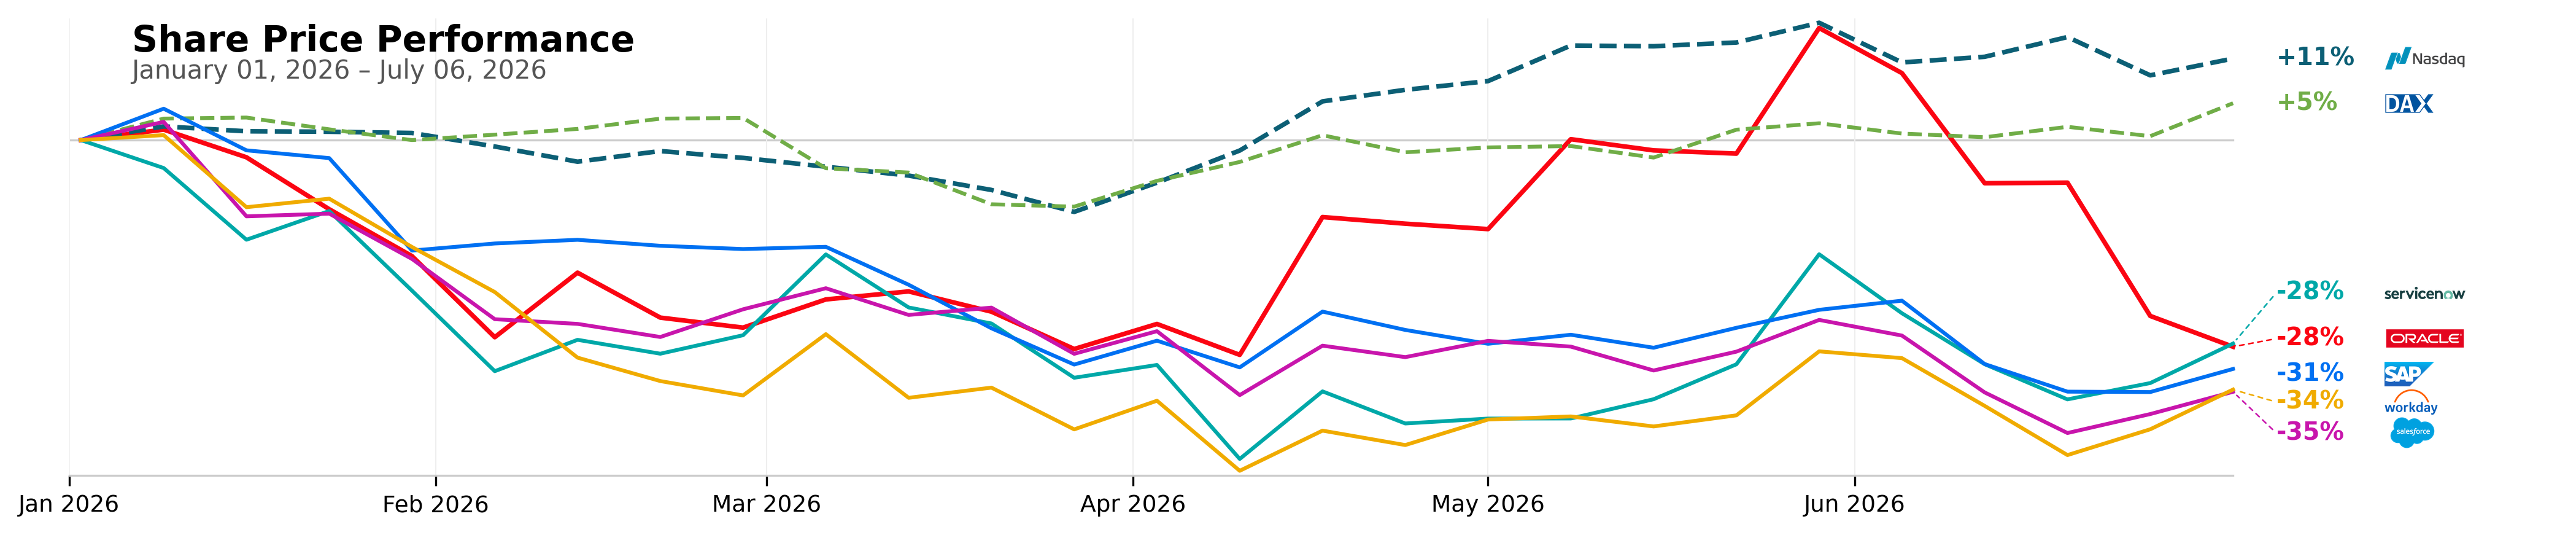

In [4]:
# ── 0) Layout & Annotation Parameters ─────────────────────────────────────────
SUBPLOT_LEFT   = 0.08
SUBPLOT_RIGHT  = 0.875
SUBPLOT_TOP    = 0.89
SUBPLOT_BOTTOM = 0.09

RIGHT_PAD_FRAC   = 0.15
PCT_OFFSET_FRAC  = 0.020
LOGO_OFFSET_FRAC = 0.070

VERT_MARGIN_PX     = 1
TEXT_FONTSIZE_PT   = 9.5
LOGO_REL_HEIGHT    = 0.08
LOGO_MAX_SCALE_UP  = 1.0

LOGO_SCALE_OVERRIDES = {
    "DAX":        0.45,
    "SAP":        0.55,
    "Salesforce": 0.69,
    "Workday":    0.67,
}

# ── 1) Configuration ───────────────────────────────────────────────────────────
START    = "2026-01-01"
END      = "2026-07-06"
LOGO_DIR = os.getcwd()

tickers = {
    "Oracle":     "ORCL",
    "Nasdaq":     "^IXIC",
    "ServiceNow": "NOW",
    "DAX":        "^GDAXI",
    "SAP":        "SAP",
    "Salesforce": "CRM",
    "Workday":    "WDAY",
}

COLORS = {
    "Oracle":     "#FB0512",
    "Nasdaq":     "#0C5F75",
    "ServiceNow": "#00A8A8",
    "DAX":        "#70AD47",
    "SAP":        "#0070F2",
    "Salesforce": "#C815AC",
    "Workday":    "#F0AB00",
}

STYLES = {
    "Oracle":     {"lw": 1.8, "ls": "-"},
    "Nasdaq":     {"lw": 1.8, "ls": "--"},
    "ServiceNow": {"lw": 1.5, "ls": "-"},
    "DAX":        {"lw": 1.5, "ls": "--"},
    "SAP":        {"lw": 1.5, "ls": "-"},
    "Salesforce": {"lw": 1.5, "ls": "-"},
    "Workday":    {"lw": 1.5, "ls": "-"},
}

LOGO_FILES = {
    "Oracle":     "oracle_logo.png",
    "Nasdaq":     "nasdaq_logo.png",
    "ServiceNow": "servicenow_logo.png",
    "DAX":        "dax_logo.png",
    "SAP":        "sap_logo.png",
    "Salesforce": "salesforce_logo.png",
    "Workday":    "workday_logo.png",
}


# ── 2) Data Retrieval ─────────────────────────────────────────────────────────
def fetch(ticker, start, end):
    df = yf.download(ticker, start=start, end=end,
                     interval="1d", auto_adjust=False, progress=False)
    s = df.get("Close")
    if s is None or s.empty:
        return pd.Series(dtype=float)
    return s.resample("W-FRI").last().ffill()


raw = {label: fetch(tck, START, END) for label, tck in tickers.items()}


# ── 3) Alignment & Performance Calculation ────────────────────────────────────
prices = pd.concat(list(raw.values()), axis=1, keys=list(raw.keys())).sort_index()
prices.columns = prices.columns.get_level_values(0)
prices = prices.dropna(how="all")
base_date = prices.dropna().index[0]
perf = (prices / prices.loc[base_date] - 1) * 100


# ── 4) Figure Setup ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 3.1), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plt.subplots_adjust(left=SUBPLOT_LEFT, right=SUBPLOT_RIGHT,
                    top=SUBPLOT_TOP, bottom=SUBPLOT_BOTTOM)


# ── 5) Plot Performance Lines ─────────────────────────────────────────────────
for label in tickers:
    if label in perf:
        ax.plot(perf[label].index, perf[label].values,
                color=COLORS[label], linewidth=STYLES[label]["lw"],
                linestyle=STYLES[label]["ls"], zorder=3)


# ── 6) Axis Styling ───────────────────────────────────────────────────────────


# X-axis: one tick per month Jan–Jun 2026, labelled "Jan 2026" etc.
tick_dates = pd.date_range("2026-01-01", "2026-06-01", freq="MS")
ax.set_xticks(tick_dates)
ax.set_xticklabels([d.strftime("%b %Y") for d in tick_dates])

# Measure the plot's pixel width using the real data range (no padding yet)
ax.set_xlim(left=pd.Timestamp(START), right=prices.index[-1])
fig.canvas.draw()
axis_width_px = ax.get_window_extent().width
total_days = (prices.index[-1] - pd.Timestamp(START)).days
px_per_day = axis_width_px / total_days

def frac_to_timedelta(frac):
    return pd.Timedelta(days=(axis_width_px * frac) / px_per_day)

RIGHT_PAD   = frac_to_timedelta(RIGHT_PAD_FRAC)
PCT_OFFSET  = frac_to_timedelta(PCT_OFFSET_FRAC)
LOGO_OFFSET = frac_to_timedelta(LOGO_OFFSET_FRAC)

# Now set the real x-limits, including the right-side padding
ax.set_xlim(left=pd.Timestamp(START),
            right=prices.index[-1] + RIGHT_PAD)

ax.plot([ax.get_xlim()[0], mdates.date2num(prices.index[-1])], [0, 0],
        color="#cccccc", lw=0.8, zorder=1)

ax.tick_params(axis="x", labelsize=9, length=4)
ax.yaxis.set_visible(False)

for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.spines["bottom"].set_bounds(ax.get_xlim()[0], mdates.date2num(prices.index[-1]))
ax.grid(axis="x", color="#eeeeee", lw=0.5)
ax.margins(y=0.01)


# ── 7) Logo Loading ────────────────────────────────────────────────────────────
fig.canvas.draw()
fig_w_px, fig_h_px = (fig.get_size_inches() * fig.dpi)
target_logo_h = int(round(fig_h_px * LOGO_REL_HEIGHT))


def load_logo_best(path, target_h_pix, max_scale_up=1.0):
    img = Image.open(path).convert("RGBA")
    w, h = img.size
    allowed_h = int(round(min(h * max_scale_up, target_h_pix)))
    final_h = max(1, allowed_h)
    if final_h != h:
        new_w = int(round(w * final_h / h))
        img = img.resize((new_w, final_h), Image.LANCZOS)
        w, h = new_w, final_h
    return np.array(img), h, w, img


logos = {}
logo_heights = {}
logo_widths = {}

for label, fname in LOGO_FILES.items():
    path = os.path.join(LOGO_DIR, fname)
    if os.path.exists(path):
        scale = LOGO_SCALE_OVERRIDES.get(label, 1.0)
        arr, final_h, final_w, _ = load_logo_best(
            path, int(target_logo_h * scale), LOGO_MAX_SCALE_UP)
        logos[label] = arr
        logo_heights[label] = final_h
        logo_widths[label] = final_w


# ── 8) Collision Avoidance ────────────────────────────────────────────────────
final_vals = {lbl: perf[lbl].dropna().iloc[-1] for lbl in perf.columns}
sorted_labels = sorted(final_vals, key=final_vals.get, reverse=True)
base_logo_x = prices.index[-1] + LOGO_OFFSET

last_valid_x = {}
for lbl in sorted_labels:
    s = perf[lbl].dropna()
    last_valid_x[lbl] = s.index[-1] if len(s) else prices.index[-1]

logo_x = base_logo_x


def data_y_to_pix(y):
    return ax.transData.transform((mdates.date2num(logo_x), y))[1]

def pix_to_data_y(pix):
    return ax.transData.inverted().transform((mdates.date2num(logo_x), pix))[1]

def pix_per_data_unit():
    p0 = data_y_to_pix(0.0)
    p1 = data_y_to_pix(1.0)
    return (p1 - p0) if (p1 - p0) != 0 else 1.0

def data_dy_from_pix(dy_pix):
    return dy_pix / pix_per_data_unit()


text_px = int(round(fig.dpi * TEXT_FONTSIZE_PT / 72.0))
base_text_gap_px = text_px + 4
margin_px = VERT_MARGIN_PX

ax_bbox = ax.get_window_extent()
y_min_pix = ax_bbox.y0
y_max_pix = ax_bbox.y1

adj_pix = [data_y_to_pix(final_vals[lbl]) for lbl in sorted_labels]
item_heights = [logo_heights.get(lbl, base_text_gap_px) for lbl in sorted_labels]

for _ in range(200):
    moved = False
    for i in range(1, len(adj_pix)):
        prev_h = item_heights[i - 1]
        curr_h = item_heights[i]
        min_gap_px = (prev_h / 2) + (curr_h / 2) + margin_px
        overlap = min_gap_px - (adj_pix[i - 1] - adj_pix[i])
        if overlap > 0.5:
            adj_pix[i - 1] += overlap / 2
            adj_pix[i]     -= overlap / 2
            moved = True
    if adj_pix[0] + item_heights[0] / 2 > y_max_pix:
        adj_pix[0] = y_max_pix - item_heights[0] / 2
        moved = True
    if adj_pix[-1] - item_heights[-1] / 2 < y_min_pix:
        shift = y_min_pix - (adj_pix[-1] - item_heights[-1] / 2)
        adj_pix = [p + shift for p in adj_pix]
        moved = True
    if not moved:
        break

positions = {lbl: pix_to_data_y(adj_pix[i]) for i, lbl in enumerate(sorted_labels)}


# ── 9) Percentage Labels & Leader Lines ───────────────────────────────────────
PCT_X = prices.index[-1] + PCT_OFFSET

for label in sorted_labels:
    val   = final_vals[label]
    y_adj = positions[label]
    y_raw = final_vals[label]
    x_end = last_valid_x[label]
    sign  = "+" if val >= 0 else ""

    if abs(y_adj - y_raw) > 1.0:
        ax.annotate("", xy=(x_end, y_raw), xytext=(PCT_X, y_adj),
                    arrowprops=dict(arrowstyle="-", color=COLORS[label],
                                    lw=0.6, linestyle=(0, (3, 3)),
                                    connectionstyle="arc3,rad=0.0"),
                    annotation_clip=False, zorder=2)

    ax.annotate(f"{sign}{val:.0f}%", xy=(PCT_X, y_adj),
                fontsize=TEXT_FONTSIZE_PT, color=COLORS[label],
                va="center", ha="left", fontweight="bold",
                annotation_clip=False, zorder=9)


# ── 10) Logo Placement ────────────────────────────────────────────────────────
fig.canvas.draw()

for label in sorted_labels:
    if label not in logos:
        continue
    img_arr = logos[label]
    y_data  = positions[label]
    x_disp, y_disp = ax.transData.transform((mdates.date2num(logo_x), y_data))
    h_px = img_arr.shape[0]
    w_px = img_arr.shape[1]
    fig_w_px, fig_h_px = (fig.get_size_inches() * fig.dpi)
    x0     = x_disp / fig_w_px
    y0     = (y_disp - h_px / 2) / fig_h_px
    w_frac = w_px / fig_w_px
    h_frac = h_px / fig_h_px
    logo_ax = fig.add_axes([x0, y0, w_frac, h_frac], zorder=10)
    logo_ax.imshow(img_arr, aspect="auto", interpolation="none")
    logo_ax.axis("off")


# ── 11) Chart Title ───────────────────────────────────────────────────────────
fig.text(0.10, 0.88, "Share Price Performance",
         fontsize=14, fontweight="bold", va="top", ha="left")
fig.text(0.1, 0.82,
         f"{pd.Timestamp(START).strftime('%B %d, %Y')} – {pd.Timestamp(END).strftime('%B %d, %Y')}",
         fontsize=10, color="#555555", va="top", ha="left")


# ── 12) Export Figure ─────────────────────────────────────────────────────────
plt.savefig("share_price_performance_last_year_v2.png", dpi=300)
print("Saved → share_price_performance_last_year_v2.png")
plt.show()